In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv("/content/siata_crudo_18-23.csv")
df["fecha"] = pd.to_datetime(df["fecha"])
df.set_index('fecha', inplace=True)
df["fecha"]=df.index

b = []
for col in df.fecha:
  b.append(col.hour)
df["Hora"] = b

df

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-01-01 00:00:00,18.605000,849.493333,78.423333,2.918333,6.966667,NaN,0.0,0.0,2018-01-01 00:00:00,2018-01-01 00:00:00,0
2018-01-01 01:00:00,18.110000,848.941667,78.426667,1.953333,10.200000,NaN,0.0,0.0,2018-01-01 01:00:00,2018-01-01 01:00:00,1
2018-01-01 02:00:00,17.688333,848.656667,79.396667,1.005000,18.083333,NaN,0.0,0.0,2018-01-01 02:00:00,2018-01-01 02:00:00,2
2018-01-01 03:00:00,17.135000,848.238333,81.558333,1.133333,12.533333,NaN,0.0,0.0,2018-01-01 03:00:00,2018-01-01 03:00:00,3
2018-01-01 04:00:00,17.368333,848.398333,79.163333,0.726667,12.966667,0.0,0.0,0.0,2018-01-01 04:00:00,2018-01-01 04:00:00,4
...,...,...,...,...,...,...,...,...,...,...,...
2023-02-28 19:00:00,24.288333,846.723333,64.780000,5.110000,7.433333,NaN,0.0,0.0,2023-02-28 19:00:00,2023-02-28 19:00:00,19
2023-02-28 20:00:00,23.381667,847.721667,68.931667,4.776667,6.916667,NaN,0.0,0.0,2023-02-28 20:00:00,2023-02-28 20:00:00,20
2023-02-28 21:00:00,22.451667,848.585000,76.561667,4.641667,7.750000,NaN,0.0,0.0,2023-02-28 21:00:00,2023-02-28 21:00:00,21


In [ ]:
n=200
a=18
b=23
top_prec = df.sort_values(by='Precipitacion', ascending=False).head(n)
#top_prec[['Precipitacion']]
top_prec = df[(df["Hora"]>=a) & (df["Hora"]<=b) & (df["Precipitacion"]>2)]
top_prec

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-01-02 19:00:00,18.228333,847.426667,81.343333,3.118333,7.083333,NaN,2.04,0.0,2018-01-02 19:00:00,2018-01-02 19:00:00,19
2018-01-03 22:00:00,18.560000,849.030000,76.133333,2.228333,21.466667,NaN,2.04,0.0,2018-01-03 22:00:00,2018-01-03 22:00:00,22
2018-02-23 18:00:00,16.727660,848.515000,80.325000,2.351667,8.483333,0.0,2.54,0.0,2018-02-23 18:00:00,2018-02-23 18:00:00,18
2018-03-23 22:00:00,17.868333,849.061667,83.813333,1.388333,16.916667,0.0,2.70,0.0,2018-03-23 22:00:00,2018-03-23 22:00:00,22
2018-03-24 20:00:00,19.860000,847.190000,77.825000,3.383051,8.900000,0.0,2.35,0.0,2018-03-24 20:00:00,2018-03-24 20:00:00,20
...,...,...,...,...,...,...,...,...,...,...,...
2022-11-08 20:00:00,17.015000,850.888462,94.043750,0.841667,29.100000,NaN,2.72,0.0,2022-11-08 20:00:00,2022-11-08 20:00:00,20
2022-11-09 21:00:00,17.313333,850.771667,94.271429,0.925000,15.900000,0.0,2.22,0.0,2022-11-09 21:00:00,2022-11-09 21:00:00,21
2022-11-09 22:00:00,17.443333,850.975510,NaN,0.551667,17.950000,0.0,2.26,0.0,2022-11-09 22:00:00,2022-11-09 22:00:00,22


In [ ]:
a=0
b=6
df[(df["Hora"]>=a) & (df["Hora"]<b) & (df["Precipitacion"]>0)]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-01-02 00:00:00,17.621667,849.631667,85.026667,1.258333,12.083333,0.0,1.87,0.0,2018-01-02 00:00:00,2018-01-02 00:00:00,0
2018-01-02 01:00:00,17.401667,848.798333,83.670000,1.468333,6.216667,0.0,0.34,0.0,2018-01-02 01:00:00,2018-01-02 01:00:00,1
2018-01-03 01:00:00,17.800000,848.073333,83.876667,1.511667,14.600000,0.0,0.04,0.0,2018-01-03 01:00:00,2018-01-03 01:00:00,1
2018-01-03 03:00:00,17.713333,847.210000,84.325000,1.835000,12.600000,NaN,0.06,0.0,2018-01-03 03:00:00,2018-01-03 03:00:00,3
2018-01-04 01:00:00,17.698333,849.370000,80.601667,0.735000,18.733333,NaN,1.96,0.0,2018-01-04 01:00:00,2018-01-04 01:00:00,1
...,...,...,...,...,...,...,...,...,...,...,...
2023-02-15 01:00:00,20.495000,846.633333,80.973333,3.568333,12.933333,NaN,0.04,0.0,2023-02-15 01:00:00,2023-02-15 01:00:00,1
2023-02-15 03:00:00,19.541667,846.431667,83.676667,3.570000,8.683333,NaN,0.20,0.0,2023-02-15 03:00:00,2023-02-15 03:00:00,3
2023-02-15 04:00:00,18.658333,846.518333,88.706667,1.821667,13.166667,NaN,0.65,0.0,2023-02-15 04:00:00,2023-02-15 04:00:00,4


In [ ]:
len(top_prec.fecha),  len(df[(df["Precipitacion"]>2)]["Precipitacion"])

(222, 658)

In [ ]:
df[variable[i]]<=Barras["xmax"].iloc[i]

NameError: ignored

In [ ]:
Barras["xmax"].iloc[0]

NameError: ignored

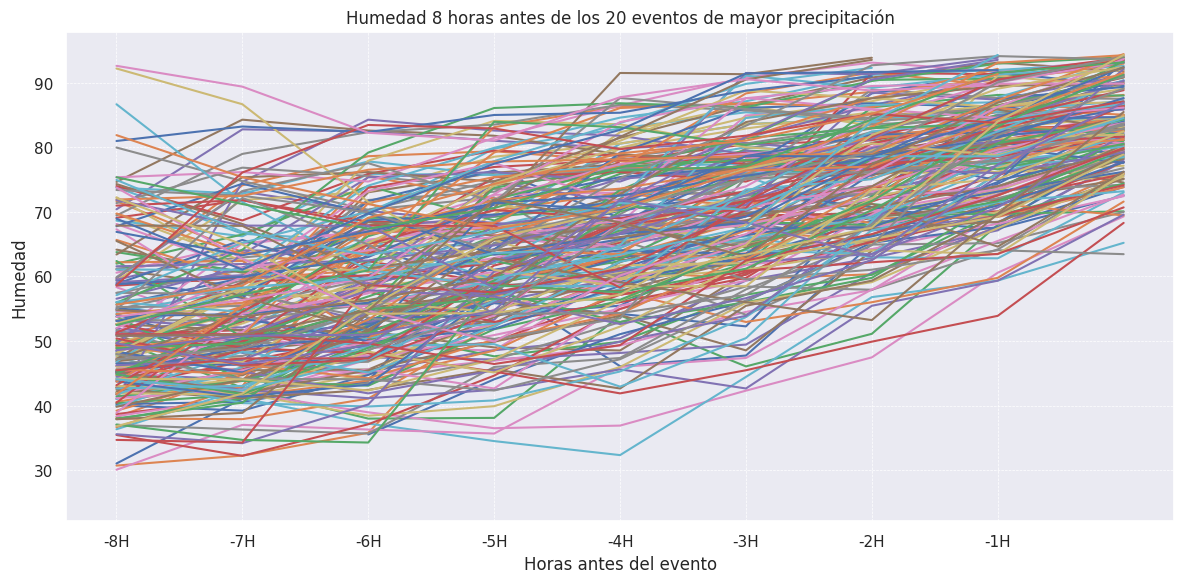

In [ ]:
# Función para obtener los datos de humedad 8 horas antes de un evento
n=len(top_prec.fecha)

horas=8
variable="Humedad"

def var_antes_evento(evento, horas,variable):
    end_time = evento
    start_time = end_time - pd.Timedelta(hours=horas)
    subset = df[(df['fecha'] >= start_time) & (df['fecha'] <= end_time)]
    return subset[variable]

# Preparar la figura para el gráfico
plt.figure(figsize=(12, 6))
hann=np.zeros((9,n+1))
hann[:,0] = [0,-1,-2,-3,-4,-5,-6,-7,-8]

# Graficar las series de tiempo superpuestas
for i,evento in enumerate(top_prec['fecha']):
    var_data = var_antes_evento(evento,horas,variable)
    hann[:,i+1]=var_data.values
    plt.plot(var_data.values)

# Configurar el gráfico
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.xticks(ticks=range(horas), labels=[f"-{horas-i}H" for i in range(horas)])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [ ]:
hann[:,:5]

array([[ 0.        , 45.50666667, 38.265     , 50.16166667, 38.705     ],
       [-1.        , 46.81333333, 45.14333333, 42.775     , 41.045     ],
       [-2.        , 64.39666667, 52.45      , 38.01      , 50.22      ],
       [-3.        , 58.77166667, 62.61666667, 38.12166667, 61.685     ],
       [-4.        , 46.11666667, 60.8       , 53.98333333, 66.86      ],
       [-5.        , 47.76833333, 59.64166667, 46.08666667, 68.325     ],
       [-6.        , 65.05      , 60.33333333, 51.12833333, 72.01333333],
       [-7.        , 71.295     , 67.675     , 67.995     , 73.45666667],
       [-8.        , 81.34333333, 76.13333333, 80.325     , 83.81333333]])

In [ ]:
h = np.zeros(9)
std = np.zeros(9)
for i in range(9):
    h[i] = np.mean(hann[i,1:][~np.isnan(hann[i,1:])])
    std[i] = np.std(hann[i,1:][~np.isnan(hann[i,1:])])

plt.plot(hann[:,0],np.flip(h),label="Media de valores",color="black")
plt.plot(hann[:,0],np.flip(h)+np.flip(std),label="Desviación estan]dar",color="blue")
plt.plot(hann[:,0],np.flip(h)-np.flip(std),color="blue")
plt.fill_between(hann[:,0], np.flip(h)-np.flip(std), np.flip(h)+np.flip(std), color='blue',alpha=0.2)
plt.legend()
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')


#HACER GRAFICA DE VIOLINES SOBRE LA DISTRIBUCION

Text(0.5, 1.0, 'Humedad 8 horas antes de los 20 eventos de mayor precipitación')

In [ ]:
BarrasH = pd.DataFrame({"t":np.arange(9),"xmin":h-std,"xmax":h+std})
#BarrasH.t[0]=0
BarrasH

,t,xmin,xmax
0,0,40.506156,64.337198
1,1,42.972356,65.591234
2,2,46.811155,69.424213
3,3,51.724095,73.443491
4,4,55.699799,77.415928
5,5,60.269692,81.565673
6,6,65.966306,84.905599
7,7,71.384019,87.748716
8,8,77.028021,90.100612


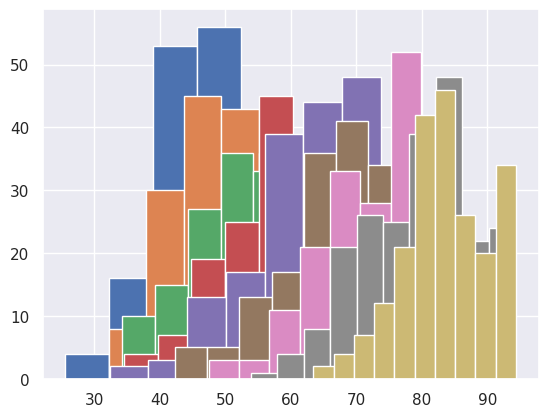

In [ ]:
for i in range(9):
    plt.hist(hann[i,1:][~np.isnan(hann[i,1:])])
    #plt.show()

In [ ]:
n=200
a=18
b=23

df_Barras= BarrasH.copy()

def barras(precip,hora1,hora2):

  top_prec = df[(df["Hora"]>=hora1) & (df["Hora"]<=hora2) & (df["Precipitacion"]>precip)]

  # Función para obtener los datos de humedad 8 horas antes de un evento
  n=len(top_prec.fecha)

  horas=8
  variable = ["Temperatura", "Presion", "Humedad", "VeloViento"]

  def var_antes_evento(evento, horas,variable):
      end_time = evento
      start_time = end_time - pd.Timedelta(hours=horas)
      subset = df[(df['fecha'] >= start_time) & (df['fecha'] <= end_time)]
      return subset[variable]

  # Preparar la figura para el gráfico
  hann=np.zeros((9,n+1))
  hann[:,0] = [0,-1,-2,-3,-4,-5,-6,-7,-8]

  for iterador in range(len(variable)):

    # Graficar las series de tiempo superpuestas
    for i,evento in enumerate(top_prec['fecha']):
        var_data = var_antes_evento(evento,horas,variable[iterador])
        hann[:,i+1]=var_data.values

    h = np.zeros(9)
    std = np.zeros(9)
    for i in range(9):
        h[i] = np.mean(hann[i,1:][~np.isnan(hann[i,1:])])
        std[i] = np.std(hann[i,1:][~np.isnan(hann[i,1:])])

    BarrasH = pd.DataFrame({"t":np.arange(9),"xmin":h-std,"xmax":h+std})

    df_Barras.iloc[iterador] = BarrasH.iloc[8]
    df_Barras.t.iloc[iterador] = variable[iterador]
  return df_Barras[:4]

In [ ]:
TPrec=1.5
hora1=18
hora2=23

Barras = barras(TPrec,hora1,hora2)
#Barras["t"]=Barras.index
Barras

<ipython-input-10-e1f0a2508dc3>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Barras.t.iloc[iterador] = variable[iterador]
<ipython-input-10-e1f0a2508dc3>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Barras.t.iloc[iterador] = variable[iterador]
<ipython-input-10-e1f0a2508dc3>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Barras.t.iloc[iterador] = variable[iterador]
<ipython-input-10-e1f0a2508dc3>:43: SettingWithCo

,t,xmin,xmax
0,Temperatura,17.421328,19.636631
1,Presion,847.950816,850.309715
2,Humedad,76.605176,89.922524
3,VeloViento,0.688699,3.461693


In [ ]:
df[df["Precipitacion"]>0.2]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-01-01 17:00:00,19.725000,846.741667,74.305000,3.240000,10.783333,3.166667,0.82,0.0,2018-01-01 17:00:00,2018-01-01 17:00:00,17
2018-01-01 18:00:00,17.698333,848.161667,75.931667,3.320000,6.533333,0.000000,1.68,0.0,2018-01-01 18:00:00,2018-01-01 18:00:00,18
2018-01-01 19:00:00,17.560000,848.613333,83.450000,0.856667,13.733333,NaN,0.87,0.0,2018-01-01 19:00:00,2018-01-01 19:00:00,19
2018-01-01 23:00:00,18.088333,850.126667,80.473333,1.035000,20.266667,NaN,0.71,0.0,2018-01-01 23:00:00,2018-01-01 23:00:00,23
2018-01-02 00:00:00,17.621667,849.631667,85.026667,1.258333,12.083333,0.000000,1.87,0.0,2018-01-02 00:00:00,2018-01-02 00:00:00,0
...,...,...,...,...,...,...,...,...,...,...,...
2023-02-20 18:00:00,17.583333,846.813333,92.992683,1.456667,8.300000,0.294118,0.77,0.0,2023-02-20 18:00:00,2023-02-20 18:00:00,18
2023-02-21 13:00:00,22.743333,846.281667,61.661667,3.000000,11.816667,201.350000,0.43,0.0,2023-02-21 13:00:00,2023-02-21 13:00:00,13
2023-02-23 14:00:00,26.706667,845.690000,49.143333,5.150847,10.566667,607.666667,0.48,0.0,2023-02-23 14:00:00,2023-02-23 14:00:00,14


In [ ]:
TPrec=1.5
hora1=18
hora2=23

Barras = barras(TPrec,hora1,hora2)

df_filter = df.copy() #df[(df["Hora"]>=hora1) & (df["Hora"]<=hora2)]# & (df["Precipitacion"]>TPrec)]

variable = ["Temperatura", "Presion", "Humedad", "VeloViento"]
counts = ["CountsT", "CountsP", "CountsH", "CountsV"]

for i in range(len(Barras)):
  tf = (df_filter[variable[i]]<=Barras["xmax"].iloc[i]) & (df_filter[variable[i]]>=Barras["xmin"].iloc[i])
  df_filter[f"{counts[i]}"] = tf.astype(int)

df_filter["SumCounts"] = df_filter.CountsT + df_filter.CountsP +df_filter.CountsH +df_filter.CountsV

df_filter

<ipython-input-10-e1f0a2508dc3>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Barras.t.iloc[iterador] = variable[iterador]
<ipython-input-10-e1f0a2508dc3>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Barras.t.iloc[iterador] = variable[iterador]
<ipython-input-10-e1f0a2508dc3>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Barras.t.iloc[iterador] = variable[iterador]
<ipython-input-10-e1f0a2508dc3>:43: SettingWithCo

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora,CountsT,CountsP,CountsH,CountsV,SumCounts
fecha,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,18.605000,849.493333,78.423333,2.918333,6.966667,NaN,0.0,0.0,2018-01-01 00:00:00,2018-01-01 00:00:00,0,1,1,1,1,4
2018-01-01 01:00:00,18.110000,848.941667,78.426667,1.953333,10.200000,NaN,0.0,0.0,2018-01-01 01:00:00,2018-01-01 01:00:00,1,1,1,1,1,4
2018-01-01 02:00:00,17.688333,848.656667,79.396667,1.005000,18.083333,NaN,0.0,0.0,2018-01-01 02:00:00,2018-01-01 02:00:00,2,1,1,1,1,4
2018-01-01 03:00:00,17.135000,848.238333,81.558333,1.133333,12.533333,NaN,0.0,0.0,2018-01-01 03:00:00,2018-01-01 03:00:00,3,0,1,1,1,3
2018-01-01 04:00:00,17.368333,848.398333,79.163333,0.726667,12.966667,0.0,0.0,0.0,2018-01-01 04:00:00,2018-01-01 04:00:00,4,0,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-28 19:00:00,24.288333,846.723333,64.780000,5.110000,7.433333,NaN,0.0,0.0,2023-02-28 19:00:00,2023-02-28 19:00:00,19,0,0,0,0,0
2023-02-28 20:00:00,23.381667,847.721667,68.931667,4.776667,6.916667,NaN,0.0,0.0,2023-02-28 20:00:00,2023-02-28 20:00:00,20,0,0,0,0,0
2023-02-28 21:00:00,22.451667,848.585000,76.561667,4.641667,7.750000,NaN,0.0,0.0,2023-02-28 21:00:00,2023-02-28 21:00:00,21,0,1,0,0,1


In [ ]:
df_filter[(df_filter["SumCounts"]==3) & (df_filter["Precipitacion"]>0.2) & (df_filter["Hora"]>=hora1) & (df_filter["Hora"]<=hora2)]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora,CountsT,CountsP,CountsH,CountsV,SumCounts
fecha,,,,,,,,,,,,,,,,
2018-01-01 18:00:00,17.698333,848.161667,75.931667,3.320000,6.533333,0.0,1.68,0.0,2018-01-01 18:00:00,2018-01-01 18:00:00,18,1,1,0,1,3
2018-01-02 19:00:00,18.228333,847.426667,81.343333,3.118333,7.083333,NaN,2.04,0.0,2018-01-02 19:00:00,2018-01-02 19:00:00,19,1,0,1,1,3
2018-01-03 22:00:00,18.560000,849.030000,76.133333,2.228333,21.466667,NaN,2.04,0.0,2018-01-03 22:00:00,2018-01-03 22:00:00,22,1,1,0,1,3
2018-01-08 19:00:00,18.895000,846.911667,79.751667,1.905000,25.950000,NaN,0.44,0.0,2018-01-08 19:00:00,2018-01-08 19:00:00,19,1,0,1,1,3
2018-01-09 23:00:00,16.923333,849.518333,80.478333,1.420000,4.050000,NaN,0.37,0.0,2018-01-09 23:00:00,2018-01-09 23:00:00,23,0,1,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-03 20:00:00,17.680000,849.853333,89.608333,0.580000,20.833333,NaN,0.30,0.0,2023-01-03 20:00:00,2023-01-03 20:00:00,20,1,1,1,0,3
2023-01-07 21:00:00,19.706667,849.893333,85.151667,3.173333,8.533333,0.0,1.52,0.0,2023-01-07 21:00:00,2023-01-07 21:00:00,21,0,1,1,1,3
2023-01-18 20:00:00,18.096667,848.673333,88.731667,0.540000,14.700000,0.0,0.45,0.0,2023-01-18 20:00:00,2023-01-18 20:00:00,20,1,1,1,0,3


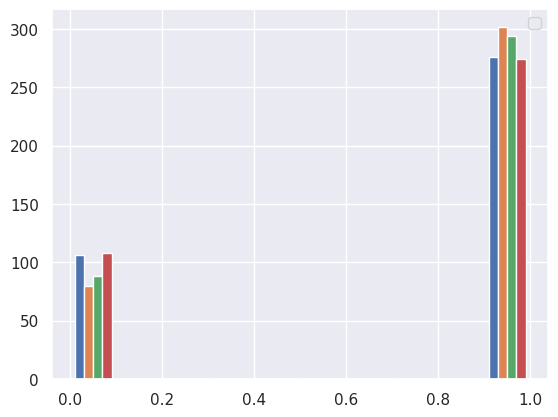

In [ ]:
plt.hist(df_filter[(df_filter["SumCounts"]==3) & (df_filter["Precipitacion"]>=0.2) & (df_filter["Hora"]>=hora1) & (df_filter["Hora"]<=hora2)][["CountsP","CountsT","CountsV","CountsH"]])
plt.legend()

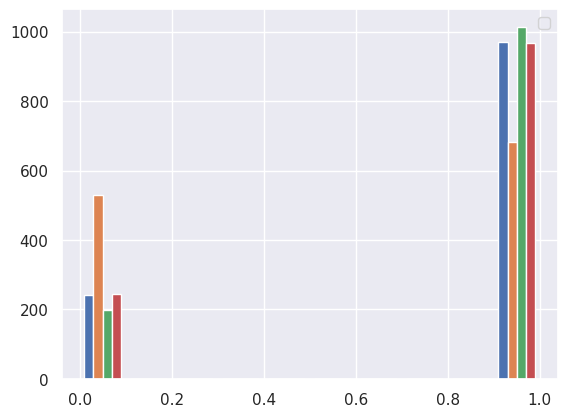

In [ ]:
plt.hist(df_filter[(df_filter["SumCounts"]==3) & (df_filter["Precipitacion"]<0.2) & (df_filter["Hora"]>=hora1) & (df_filter["Hora"]<=hora2)][["CountsP","CountsT","CountsV","CountsH"]])
plt.legend()

In [ ]:
eventos_lluvia=len(df_filter[(df_filter["CountsT"]==1) & (df_filter["CountsH"]==1)& (df_filter["CountsP"]==1)& (df_filter["Hora"]>=hora1) & (df_filter["Hora"]<=hora2)& (df_filter["Precipitacion"]<0.2)])
eventos_nolluvia=len(df_filter[(df_filter["CountsT"]==1) & (df_filter["CountsH"]==1)& (df_filter["CountsP"]==1)& (df_filter["Hora"]>=hora1) & (df_filter["Hora"]<=hora2)])
print(f"El número de evento que se encuentran entre las barras de error creadas y son eventos de lluvia son {eventos_lluvia} y los que no son eventos de lluvia son {eventos_nolluvia}")

El número de evento que se encuentran entre las barras de error creadas y son eventos de lluvia son 835 y los que no son eventos de lluvia son 1207


957

In [ ]:
np.sum(df_filter["CountsT"]),np.sum(df_filter["CountsP"]),np.sum(df_filter["CountsH"]),np.sum(df_filter["CountsV"])

(234, 244, 222, 293)

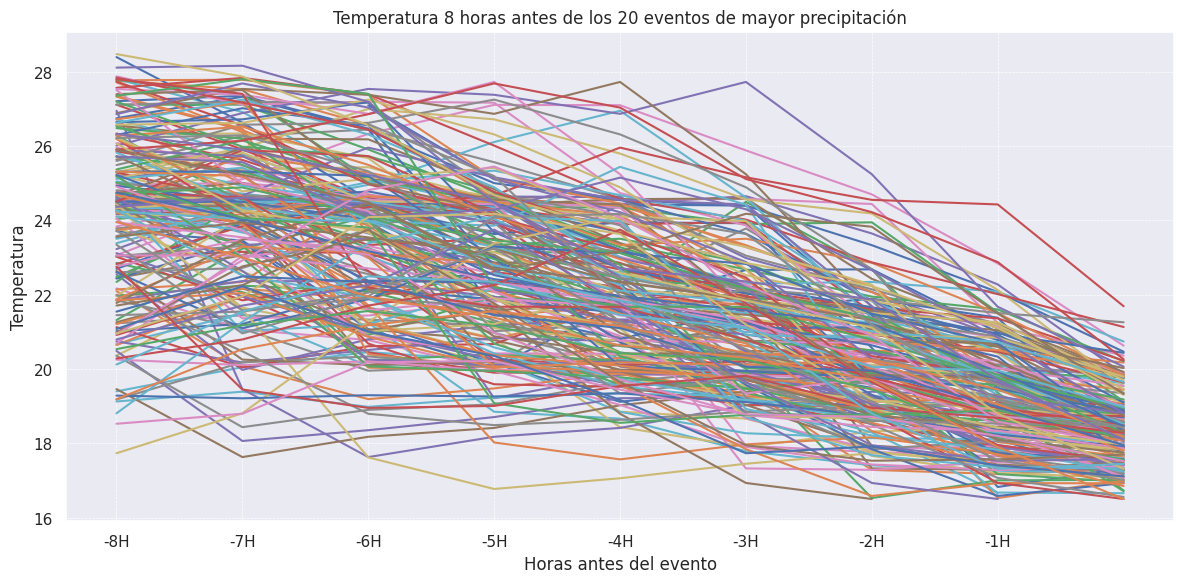

In [ ]:
variable="Temperatura"
horas=8

def var_antes_evento(evento, horas,variable):
    end_time = evento
    start_time = end_time - pd.Timedelta(hours=horas)
    subset = df[(df['fecha'] >= start_time) & (df['fecha'] <= end_time)]
    return subset[variable]

# Preparar la figura para el gráfico
plt.figure(figsize=(12, 6))
hann=np.zeros((9,n+1))
hann[:,0] = [0,-1,-2,-3,-4,-5,-6,-7,-8]

# Graficar las series de tiempo superpuestas
for i,evento in enumerate(top_prec['fecha']):
    var_data = var_antes_evento(evento,horas,variable)
    hann[:,i+1]=var_data.values
    plt.plot(var_data.values)

# Configurar el gráfico
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.xticks(ticks=range(horas), labels=[f"-{horas-i}H" for i in range(horas)])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Temperatura 8 horas antes de los 20 eventos de mayor precipitación')

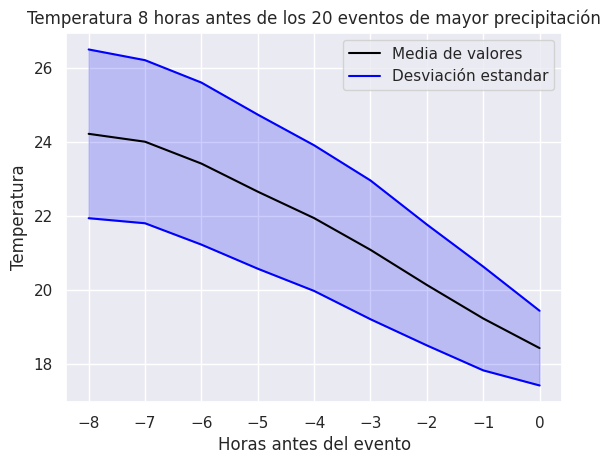

In [ ]:
h = np.zeros(9)
std = np.zeros(9)
for i in range(9):
    h[i] = np.mean(hann[i,1:][~np.isnan(hann[i,1:])])
    std[i] = np.std(hann[i,1:][~np.isnan(hann[i,1:])])
plt.plot(hann[:,0],np.flip(h),label="Media de valores",color="black")
plt.plot(hann[:,0],np.flip(h)+np.flip(std),label="Desviación estandar",color="blue")
plt.plot(hann[:,0],np.flip(h)-np.flip(std),color="blue")
plt.fill_between(hann[:,0], np.flip(h)-np.flip(std), np.flip(h)+np.flip(std), color='blue',alpha=0.2)
plt.legend()
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')

In [ ]:
BarrasT = pd.DataFrame({"t":np.arange(9),"xmin":h-std,"xmax":h+std})
#BarrasH.t[0]=0
BarrasT

,t,xmin,xmax
0,0,21.941668,26.495291
1,1,21.805222,26.205914
2,2,21.229127,25.601495
3,3,20.578758,24.736940
4,4,19.978659,23.909119
5,5,19.215160,22.959984
6,6,18.509206,21.771406
7,7,17.835846,20.635371
8,8,17.428319,19.443752


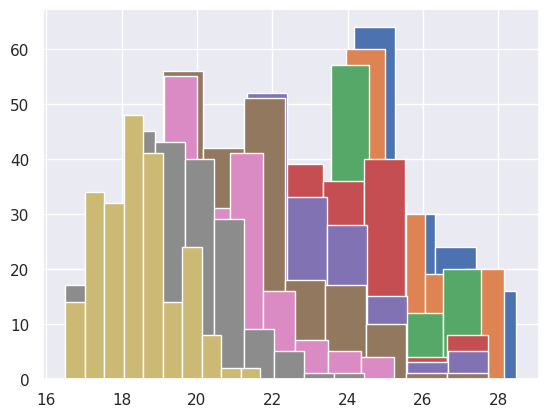

In [ ]:
for i in range(9):
    plt.hist(hann[i,1:][~np.isnan(hann[i,1:])])

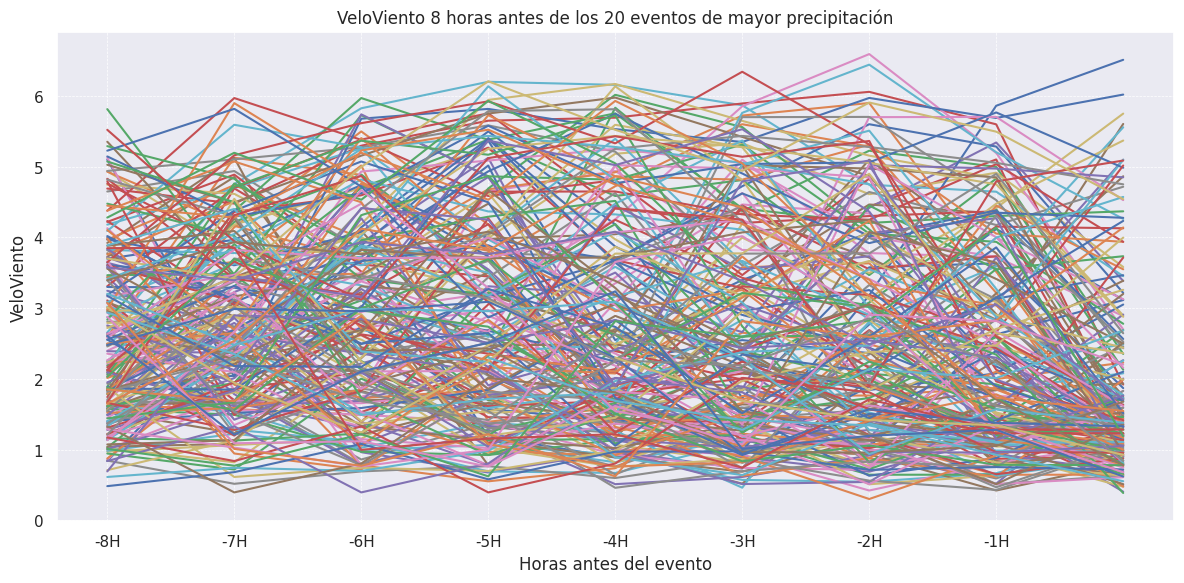

In [ ]:
variable="VeloViento"
horas=8

def var_antes_evento(evento, horas,variable):
    end_time = evento
    start_time = end_time - pd.Timedelta(hours=horas)
    subset = df[(df['fecha'] >= start_time) & (df['fecha'] <= end_time)]
    return subset[variable]

# Preparar la figura para el gráfico
plt.figure(figsize=(12, 6))
hann=np.zeros((9,n+1))
hann[:,0] = [0,-1,-2,-3,-4,-5,-6,-7,-8]

# Graficar las series de tiempo superpuestas
for i,evento in enumerate(top_prec['fecha']):
    var_data = var_antes_evento(evento,horas,variable)
    hann[:,i+1]=var_data.values
    plt.plot(var_data.values)

# Configurar el gráfico
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.xticks(ticks=range(horas), labels=[f"-{horas-i}H" for i in range(horas)])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'VeloViento 8 horas antes de los 20 eventos de mayor precipitación')

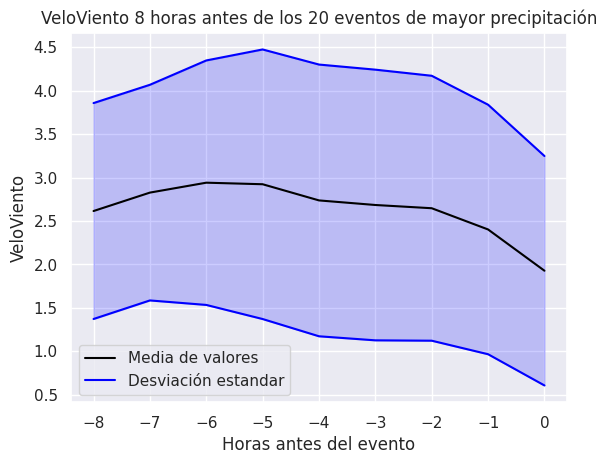

In [ ]:
h = np.zeros(9)
std = np.zeros(9)
for i in range(9):
    h[i] = np.mean(hann[i,1:][~np.isnan(hann[i,1:])])
    std[i] = np.std(hann[i,1:][~np.isnan(hann[i,1:])])
plt.plot(hann[:,0],np.flip(h),label="Media de valores",color="black")
plt.plot(hann[:,0],np.flip(h)+np.flip(std),label="Desviación estandar",color="blue")
plt.plot(hann[:,0],np.flip(h)-np.flip(std),color="blue")
plt.fill_between(hann[:,0], np.flip(h)-np.flip(std), np.flip(h)+np.flip(std), color='blue',alpha=0.2)
plt.legend()
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')

In [ ]:
BarrasV = pd.DataFrame({"t":np.arange(9),"xmin":h-std,"xmax":h+std})
#BarrasVH.t[0]=0
BarrasV

,t,xmin,xmax
0,0,1.371898,3.857054
1,1,1.585567,4.067548
2,2,1.533776,4.347570
3,3,1.371509,4.474181
4,4,1.172902,4.300395
5,5,1.126264,4.241608
6,6,1.122119,4.171277
7,7,0.966289,3.838160
8,8,0.607001,3.247753


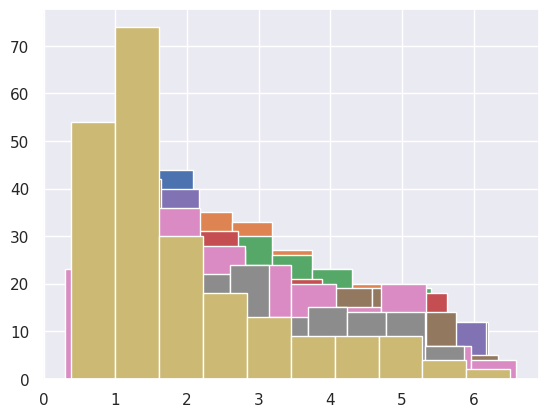

In [ ]:
for i in range(9):
    plt.hist(hann[i,1:][~np.isnan(hann[i,1:])])

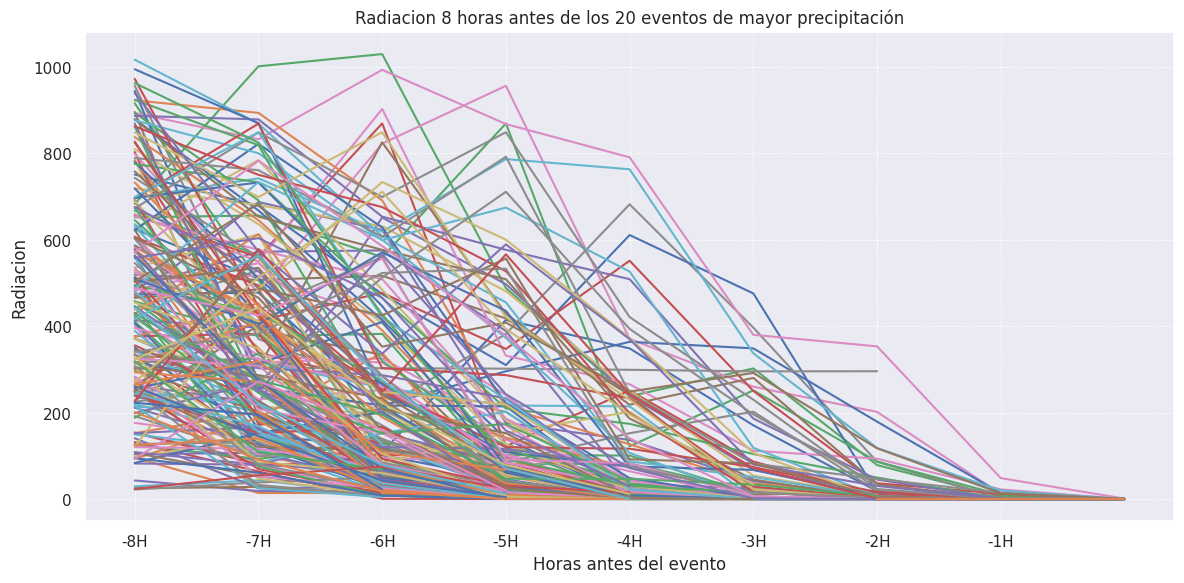

In [ ]:
variable="Radiacion"
horas=8

def var_antes_evento(evento, horas,variable):
    end_time = evento
    start_time = end_time - pd.Timedelta(hours=horas)
    subset = df[(df['fecha'] >= start_time) & (df['fecha'] <= end_time)]
    return subset[variable]

# Preparar la figura para el gráfico
plt.figure(figsize=(12, 6))
hann=np.zeros((9,n+1))
hann[:,0] = [0,-1,-2,-3,-4,-5,-6,-7,-8]

# Graficar las series de tiempo superpuestas
for i,evento in enumerate(top_prec['fecha']):
    var_data = var_antes_evento(evento,horas,variable)
    hann[:,i+1]=var_data.values
    plt.plot(var_data.values)

# Configurar el gráfico
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.xticks(ticks=range(horas), labels=[f"-{horas-i}H" for i in range(horas)])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Radiacion 8 horas antes de los 20 eventos de mayor precipitación')

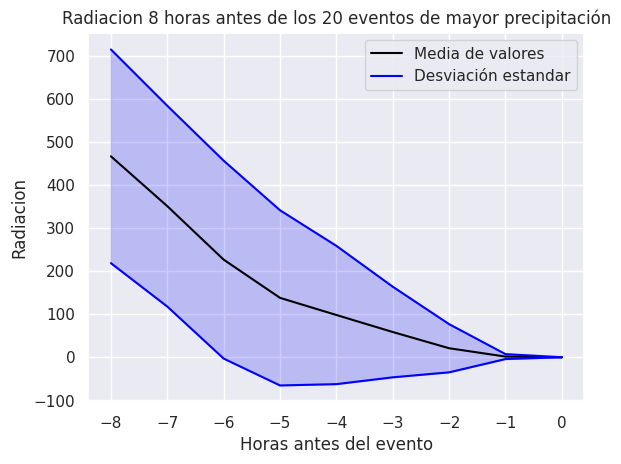

In [ ]:
h = np.zeros(9)
std = np.zeros(9)
for i in range(9):
    h[i] = np.mean(hann[i,1:][~np.isnan(hann[i,1:])])
    std[i] = np.std(hann[i,1:][~np.isnan(hann[i,1:])])
plt.plot(hann[:,0],np.flip(h),label="Media de valores",color="black")
plt.plot(hann[:,0],np.flip(h)+np.flip(std),label="Desviación estandar",color="blue")
plt.plot(hann[:,0],np.flip(h)-np.flip(std),color="blue")
plt.fill_between(hann[:,0], np.flip(h)-np.flip(std), np.flip(h)+np.flip(std), color='blue',alpha=0.2)
plt.legend()
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')

In [ ]:
BarrasR = pd.DataFrame({"t":np.arange(9),"xmin":h-std,"xmax":h+std})
#BarrasH.t[0]=0
BarrasR

,t,xmin,xmax
0,0,218.279153,714.171812
1,1,117.568718,583.511165
2,2,-3.112307,456.115166
3,3,-65.444597,341.042862
4,4,-62.377745,258.449788
5,5,-46.581842,163.685126
6,6,-34.999935,76.810590
7,7,-4.210491,7.280971
8,8,-0.064310,0.081259


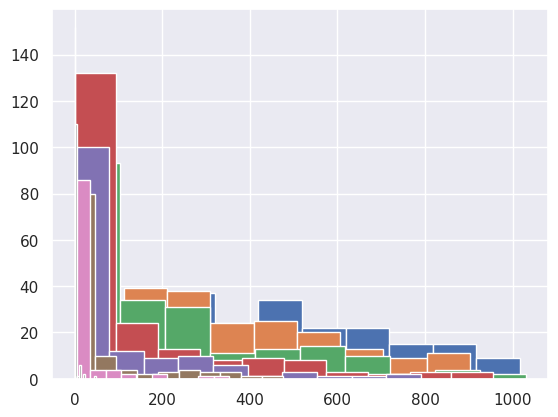

In [ ]:
for i in range(9):
    plt.hist(hann[i,1:][~np.isnan(hann[i,1:])])

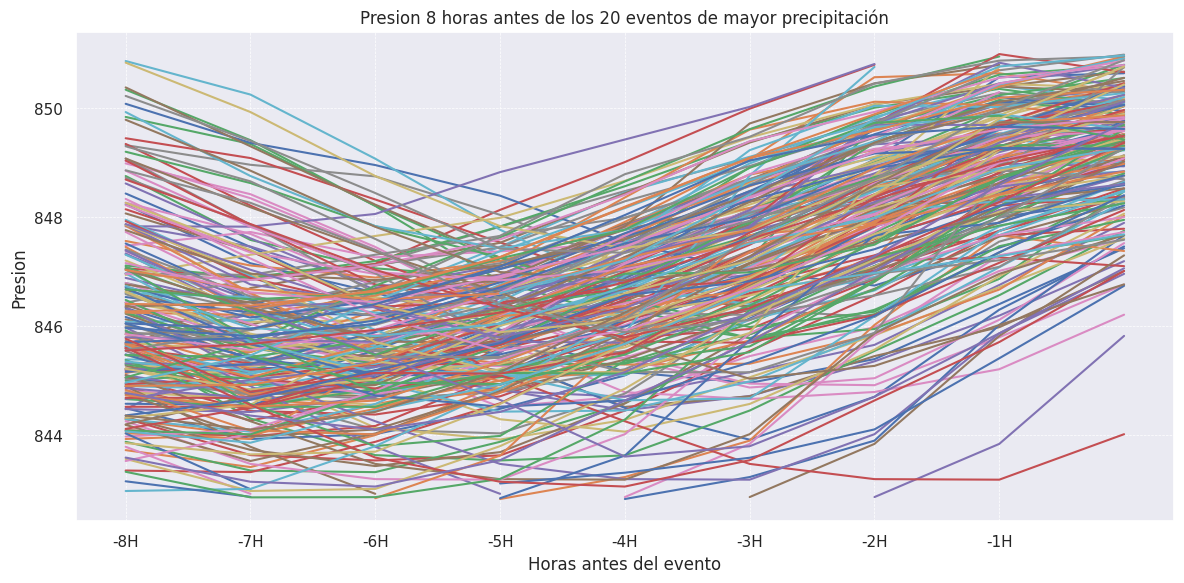

In [ ]:
variable="Presion"
horas=8

def var_antes_evento(evento, horas,variable):
    end_time = evento
    start_time = end_time - pd.Timedelta(hours=horas)
    subset = df[(df['fecha'] >= start_time) & (df['fecha'] <= end_time)]
    return subset[variable]

# Preparar la figura para el gráfico
plt.figure(figsize=(12, 6))
hann=np.zeros((9,n+1))
hann[:,0] = [0,-1,-2,-3,-4,-5,-6,-7,-8]

# Graficar las series de tiempo superpuestas
for i,evento in enumerate(top_prec['fecha']):
    var_data = var_antes_evento(evento,horas,variable)
    hann[:,i+1]=var_data.values
    plt.plot(var_data.values)

# Configurar el gráfico
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.xticks(ticks=range(horas), labels=[f"-{horas-i}H" for i in range(horas)])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Presion 8 horas antes de los 20 eventos de mayor precipitación')

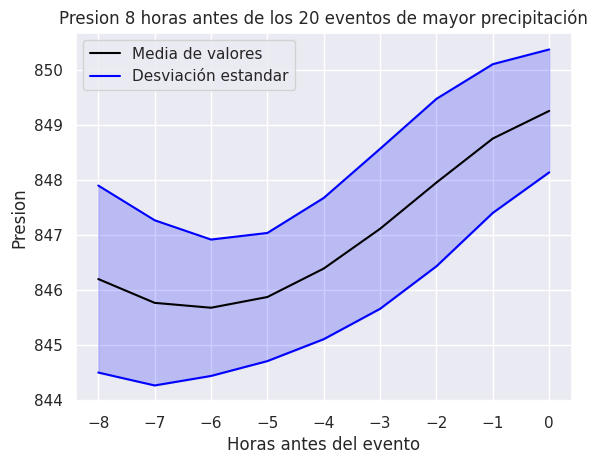

In [ ]:
h = np.zeros(9)
std = np.zeros(9)
for i in range(9):
    h[i] = np.mean(hann[i,1:][~np.isnan(hann[i,1:])])
    std[i] = np.std(hann[i,1:][~np.isnan(hann[i,1:])])
plt.plot(hann[:,0],np.flip(h),label="Media de valores",color="black")
plt.plot(hann[:,0],np.flip(h)+np.flip(std),label="Desviación estandar",color="blue")
plt.plot(hann[:,0],np.flip(h)-np.flip(std),color="blue")
plt.fill_between(hann[:,0], np.flip(h)-np.flip(std), np.flip(h)+np.flip(std), color='blue',alpha=0.2)
plt.legend()
plt.xlabel('Horas antes del evento')
plt.ylabel(f'{variable}')
plt.title(f'{variable} {horas} horas antes de los 20 eventos de mayor precipitación')

In [ ]:
BarrasP = pd.DataFrame({"t":np.arange(9),"xmin":h-std,"xmax":h+std})
#BarrasH.t[0]=0
BarrasP

,t,xmin,xmax
0,0,844.491148,847.896848
1,1,844.256006,847.264632
2,2,844.429280,846.913403
3,3,844.699816,847.033464
4,4,845.098853,847.671519
5,5,845.652354,848.566748
6,6,846.427264,849.476306
7,7,847.399200,850.107723
8,8,848.137129,850.375487


In [ ]:
df[(df.Hora >= 0) & (df.Hora < 6) & (df.Temperatura >= BarrasT.xmin[8]) & (df.Temperatura <= BarrasT.xmax[8]) & (df.Presion >= BarrasP.xmin[8]) & (df.Presion <= BarrasP.xmax[8]) & (df.VeloViento >= BarrasV.xmin[8]) & (df.VeloViento <= BarrasV.xmax[8]) & (df.Humedad >= BarrasH.xmin[8]) & (df.Humedad <= BarrasH.xmax[8]) & (df["Precipitacion"]>2)]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-01-04 02:00:00,17.343333,848.920000,82.675000,0.920000,8.500000,0.0,3.14,0.0,2018-01-04 02:00:00,2018-01-04 02:00:00,2
2018-04-27 05:00:00,17.196667,848.393333,86.695000,0.815000,25.783333,0.0,2.90,0.0,2018-04-27 05:00:00,2018-04-27 05:00:00,5
2018-04-28 03:00:00,18.121667,848.853333,88.010000,1.126667,9.616667,0.0,2.37,0.0,2018-04-28 03:00:00,2018-04-28 03:00:00,3
2018-04-28 04:00:00,17.973333,849.038333,88.995000,0.681667,13.566667,0.0,2.50,0.0,2018-04-28 04:00:00,2018-04-28 04:00:00,4
2018-04-29 02:00:00,18.473333,848.950000,83.610000,1.675000,9.650000,0.0,2.12,0.0,2018-04-29 02:00:00,2018-04-29 02:00:00,2
...,...,...,...,...,...,...,...,...,...,...,...
2022-07-13 02:00:00,18.241667,849.010000,88.060000,1.961667,10.066667,0.0,2.18,0.0,2022-07-13 02:00:00,2022-07-13 02:00:00,2
2022-07-25 03:00:00,17.958333,848.451667,84.800000,2.375000,12.800000,0.0,3.04,0.0,2022-07-25 03:00:00,2022-07-25 03:00:00,3
2022-08-01 03:00:00,17.351667,848.275000,89.637931,1.656667,14.950000,0.0,2.83,0.0,2022-08-01 03:00:00,2022-08-01 03:00:00,3


In [ ]:
df[(df.Hora >= 6) & (df.Hora < 12) & (df.Temperatura >= BarrasT.xmin[8]) & (df.Temperatura <= BarrasT.xmax[8]) & (df.Presion >= BarrasP.xmin[8]) & (df.Presion <= BarrasP.xmax[8]) & (df.VeloViento >= BarrasV.xmin[8]) & (df.VeloViento <= BarrasV.xmax[8]) & (df.Humedad >= BarrasH.xmin[8]) & (df.Humedad <= BarrasH.xmax[8]) & (df["Precipitacion"]>2)]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2019-03-19 07:00:00,17.706667,849.400000,85.190000,0.656667,33.566667,NaN,2.25,0.0,2019-03-19 07:00:00,2019-03-19 07:00:00,7
2020-06-03 08:00:00,18.560000,850.682353,78.396667,0.586667,10.150000,100.800000,4.06,0.0,2020-06-03 08:00:00,2020-06-03 08:00:00,8
2020-07-23 11:00:00,18.221667,849.686667,81.828333,1.998333,11.266667,79.050000,5.50,0.0,2020-07-23 11:00:00,2020-07-23 11:00:00,11
2020-08-01 06:00:00,18.708333,849.603333,77.733333,0.805000,19.416667,35.188679,2.64,0.0,2020-08-01 06:00:00,2020-08-01 06:00:00,6
2020-08-22 06:00:00,18.081667,849.445000,81.983333,1.303333,9.783333,4.383333,3.26,0.0,2020-08-22 06:00:00,2020-08-22 06:00:00,6
2020-08-22 07:00:00,17.818333,849.991667,79.335000,1.653333,13.850000,94.833333,3.30,0.0,2020-08-22 07:00:00,2020-08-22 07:00:00,7
2020-10-04 06:00:00,17.465000,849.665000,85.230000,0.780000,20.616667,18.716667,2.34,0.0,2020-10-04 06:00:00,2020-10-04 06:00:00,6
2020-10-31 06:00:00,17.861667,849.816667,81.605000,1.205000,15.216667,13.450000,4.90,0.0,2020-10-31 06:00:00,2020-10-31 06:00:00,6
2020-10-31 07:00:00,17.366667,850.535000,84.261667,1.143333,8.550000,65.033333,4.26,0.0,2020-10-31 07:00:00,2020-10-31 07:00:00,7


In [ ]:
df[(df.Hora >= 12) & (df.Hora < 18) & (df.Temperatura >= BarrasT.xmin[8]) & (df.Temperatura <= BarrasT.xmax[8]) & (df.Presion >= BarrasP.xmin[8]) & (df.Presion <= BarrasP.xmax[8]) & (df.VeloViento >= BarrasV.xmin[8]) & (df.VeloViento <= BarrasV.xmax[8]) & (df.Humedad >= BarrasH.xmin[8]) & (df.Humedad <= BarrasH.xmax[8]) & (df["Precipitacion"]>2)]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-11-02 16:00:00,18.061667,846.213333,82.756667,3.186667,5.816667,18.500000,2.16,0.0,2018-11-02 16:00:00,2018-11-02 16:00:00,16
2018-11-03 17:00:00,19.056667,847.051667,74.125000,1.836667,5.850000,1.181818,2.34,0.0,2018-11-03 17:00:00,2018-11-03 17:00:00,17
2018-11-22 17:00:00,19.636667,846.686667,77.168333,2.325000,8.816667,0.000000,2.34,0.0,2018-11-22 17:00:00,2018-11-22 17:00:00,17
2019-09-18 16:00:00,19.190000,846.086667,78.501667,2.600000,8.950000,104.966667,2.10,0.0,2019-09-18 16:00:00,2019-09-18 16:00:00,16
2019-12-31 16:00:00,19.668333,846.848333,77.395000,1.696667,16.900000,9.850000,2.69,0.0,2019-12-31 16:00:00,2019-12-31 16:00:00,16
2019-12-31 17:00:00,19.081667,847.030000,81.540000,1.346667,8.616667,5.450000,3.10,0.0,2019-12-31 17:00:00,2019-12-31 17:00:00,17
2020-02-21 16:00:00,18.433333,846.848333,76.831667,2.726667,13.350000,38.316667,4.58,0.0,2020-02-21 16:00:00,2020-02-21 16:00:00,16
2020-10-25 15:00:00,19.720000,846.665000,72.003333,1.741667,9.500000,145.666667,2.52,0.0,2020-10-25 15:00:00,2020-10-25 15:00:00,15
2020-10-29 17:00:00,17.900000,846.066667,82.576667,2.030000,12.383333,3.183333,2.88,0.0,2020-10-29 17:00:00,2020-10-29 17:00:00,17


In [ ]:
df[(df.Hora >= 18) & (df.Hora <= 23) & (df.Temperatura >= BarrasT.xmin[8]) & (df.Temperatura <= BarrasT.xmax[8]) & (df.Presion >= BarrasP.xmin[8]) & (df.Presion <= BarrasP.xmax[8]) & (df.VeloViento >= BarrasV.xmin[8]) & (df.VeloViento <= BarrasV.xmax[8]) & (df.Humedad >= BarrasH.xmin[8]) & (df.Humedad <= BarrasH.xmax[8])& (df["Precipitacion"]>2)]

,Temperatura,Presion,Humedad,VeloViento,DireViento,Radiacion,Precipitacion,P2,fecha.1,fecha,Hora
fecha,,,,,,,,,,,
2018-03-23 22:00:00,17.868333,849.061667,83.813333,1.388333,16.916667,0.0,2.70,0.0,2018-03-23 22:00:00,2018-03-23 22:00:00,22
2018-04-10 23:00:00,18.395000,850.081667,81.853333,1.333333,25.600000,0.0,2.24,0.0,2018-04-10 23:00:00,2018-04-10 23:00:00,23
2018-05-09 20:00:00,18.840000,849.605000,77.693333,2.003333,10.933333,0.0,2.32,0.0,2018-05-09 20:00:00,2018-05-09 20:00:00,20
2018-06-27 22:00:00,18.193333,849.590000,81.550000,1.918333,14.316667,NaN,3.16,0.0,2018-06-27 22:00:00,2018-06-27 22:00:00,22
2018-07-02 22:00:00,17.923333,849.490000,84.028333,1.755000,9.066667,NaN,2.57,0.0,2018-07-02 22:00:00,2018-07-02 22:00:00,22
...,...,...,...,...,...,...,...,...,...,...,...
2022-05-30 23:00:00,18.458333,848.766667,89.331667,1.515000,22.816667,0.0,2.63,0.0,2022-05-30 23:00:00,2022-05-30 23:00:00,23
2022-07-28 20:00:00,18.421667,849.268333,89.050000,2.643333,7.316667,0.0,2.08,0.0,2022-07-28 20:00:00,2022-07-28 20:00:00,20
2022-09-18 22:00:00,18.973333,849.273333,84.500000,1.378333,10.916667,0.0,2.90,0.0,2022-09-18 22:00:00,2022-09-18 22:00:00,22


In [ ]:
L=[]
for i in range(len(df)-8):
    if df.Humedad.iloc[i] == float(df.Humedad.iloc[i]) and df.Humedad.iloc[i] >= BarrasH.xmin[0] and df.Humedad.iloc[i] <= BarrasH.xmax[0]:
        if df.Temperatura.iloc[i] == float(df.Temperatura.iloc[i]) and df.Temperatura.iloc[i] >= BarrasT.xmin[0] and df.Temperatura.iloc[i] <= BarrasT.xmax[0]:
            if df.VeloViento.iloc[i] == float(df.VeloViento.iloc[i]) and df.VeloViento.iloc[i] >= BarrasV.xmin[0] and df.VeloViento.iloc[i] <= BarrasV.xmax[0]:
                #if df.Radiacion.iloc[i] == float(df.Radiacion.iloc[i]) and df.Radiacion.iloc[i] >= BarrasR.xmin[0] and df.Radiacion.iloc[i] <= BarrasR.xmax[0]:
                if df.Presion.iloc[i] == float(df.Presion.iloc[i]) and df.Presion.iloc[i] >= BarrasP.xmin[0] and df.Presion.iloc[i] <= BarrasP.xmax[0]:
                    #################################################################################################3
                    if df.Humedad.iloc[i+1] == float(df.Humedad.iloc[i+1]) and df.Humedad.iloc[i+1] >= BarrasH.xmin[1] and df.Humedad.iloc[i+1] <= BarrasH.xmax[1]:
                        if df.Temperatura.iloc[i+1] == float(df.Temperatura.iloc[i+1]) and df.Temperatura.iloc[i+1] >= BarrasT.xmin[1] and df.Temperatura.iloc[i+1] <= BarrasT.xmax[1]:
                            if df.VeloViento.iloc[i+1] == float(df.VeloViento.iloc[i+1]) and df.VeloViento.iloc[i+1] >= BarrasV.xmin[1] and df.VeloViento.iloc[i+1] <= BarrasV.xmax[1]:
                                #if df.Radiacion.iloc[i+1] == float(df.Radiacion.iloc[i+1]) and df.Radiacion.iloc[i+1] >= BarrasR.xmin[1] and df.Radiacion.iloc[i+1] <= BarrasR.xmax[1]:
                                if df.Presion.iloc[i+1] == float(df.Presion.iloc[i+1]) and df.Presion.iloc[i+1] >= BarrasP.xmin[1] and df.Presion.iloc[i+1] <= BarrasP.xmax[1]:
                                    #################################################################################################3
                                    if df.Humedad.iloc[i+2] == float(df.Humedad.iloc[i+2]) and df.Humedad.iloc[i+2] >= BarrasH.xmin[2] and df.Humedad.iloc[i+2] <= BarrasH.xmax[2]:
                                        if df.Temperatura.iloc[i+2] == float(df.Temperatura.iloc[i+2]) and df.Temperatura.iloc[i+2] >= BarrasT.xmin[2] and df.Temperatura.iloc[i+2] <= BarrasT.xmax[2]:
                                            if df.VeloViento.iloc[i+2] == float(df.VeloViento.iloc[i+2]) and df.VeloViento.iloc[i+2] >= BarrasV.xmin[2] and df.VeloViento.iloc[i+2] <= BarrasV.xmax[2]:
                                                #if df.Radiacion.iloc[i+2] == float(df.Radiacion.iloc[i+2]) and df.Radiacion.iloc[i+2] >= BarrasR.xmin[2] and df.Radiacion.iloc[i+2] <= BarrasR.xmax[2]:
                                                if df.Presion.iloc[i+2] == float(df.Presion.iloc[i+2]) and df.Presion.iloc[i+2] >= BarrasP.xmin[2] and df.Presion.iloc[i+2] <= BarrasP.xmax[2]:
                                                    #################################################################################################3
                                                    if df.Humedad.iloc[i+3] == float(df.Humedad.iloc[i+3]) and df.Humedad.iloc[i+3] >= BarrasH.xmin[3] and df.Humedad.iloc[i+3] <= BarrasH.xmax[3]:
                                                        if df.Temperatura.iloc[i+3] == float(df.Temperatura.iloc[i+3]) and df.Temperatura.iloc[i+3] >= BarrasT.xmin[3] and df.Temperatura.iloc[i+3] <= BarrasT.xmax[3]:
                                                            if df.VeloViento.iloc[i+3] == float(df.VeloViento.iloc[i+3]) and df.VeloViento.iloc[i+3] >= BarrasV.xmin[3] and df.VeloViento.iloc[i+3] <= BarrasV.xmax[3]:
                                                                #if df.Radiacion.iloc[i+3] == float(df.Radiacion.iloc[i+3]) and df.Radiacion.iloc[i+3] >= BarrasR.xmin[3] and df.Radiacion.iloc[i+3] <= BarrasR.xmax[3]:
                                                                if df.Presion.iloc[i+3] == float(df.Presion.iloc[i+3]) and df.Presion.iloc[i+3] >= BarrasP.xmin[3] and df.Presion.iloc[i+3] <= BarrasP.xmax[3]:
                                                                    #################################################################################################3
                                                                    if df.Humedad.iloc[i+4] == float(df.Humedad.iloc[i+4]) and df.Humedad.iloc[i+4] >= BarrasH.xmin[4] and df.Humedad.iloc[i+4] <= BarrasH.xmax[4]:
                                                                        if df.Temperatura.iloc[i+4] == float(df.Temperatura.iloc[i+4]) and df.Temperatura.iloc[i+4] >= BarrasT.xmin[4] and df.Temperatura.iloc[i+4] <= BarrasT.xmax[4]:
                                                                            if df.VeloViento.iloc[i+4] == float(df.VeloViento.iloc[i+4]) and df.VeloViento.iloc[i+4] >= BarrasV.xmin[4] and df.VeloViento.iloc[i+4] <= BarrasV.xmax[4]:
                                                                                #if df.Radiacion.iloc[i+4] == float(df.Radiacion.iloc[i+4]) and df.Radiacion.iloc[i+4] >= BarrasR.xmin[4] and df.Radiacion.iloc[i+4] <= BarrasR.xmax[4]:
                                                                                if df.Presion.iloc[i+4] == float(df.Presion.iloc[i+4]) and df.Presion.iloc[i+4] >= BarrasP.xmin[4] and df.Presion.iloc[i+4] <= BarrasP.xmax[4]:
                                                                                    #################################################################################################3
                                                                                    if df.Humedad.iloc[i+5] == float(df.Humedad.iloc[i+5]) and df.Humedad.iloc[i+5] >= BarrasH.xmin[5] and df.Humedad.iloc[i+5] <= BarrasH.xmax[5]:
                                                                                        if df.Temperatura.iloc[i+5] == float(df.Temperatura.iloc[i+5]) and df.Temperatura.iloc[i+5] >= BarrasT.xmin[5] and df.Temperatura.iloc[i+5] <= BarrasT.xmax[5]:
                                                                                            if df.VeloViento.iloc[i+5] == float(df.VeloViento.iloc[i+5]) and df.VeloViento.iloc[i+5] >= BarrasV.xmin[5] and df.VeloViento.iloc[i+5] <= BarrasV.xmax[5]:
                                                                                                #if df.Radiacion.iloc[i+5] == float(df.Radiacion.iloc[i+5]) and df.Radiacion.iloc[i+5] >= BarrasR.xmin[5] and df.Radiacion.iloc[i+5] <= BarrasR.xmax[5]:
                                                                                                if df.Presion.iloc[i+5] == float(df.Presion.iloc[i+5]) and df.Presion.iloc[i+5] >= BarrasP.xmin[5] and df.Presion.iloc[i+5] <= BarrasP.xmax[5]:
                                                                                                    #################################################################################################3
                                                                                                    if df.Humedad.iloc[i+6] == float(df.Humedad.iloc[i+6]) and df.Humedad.iloc[i+6] >= BarrasH.xmin[6] and df.Humedad.iloc[i+6] <= BarrasH.xmax[6]:
                                                                                                        if df.Temperatura.iloc[i+6] == float(df.Temperatura.iloc[i+6]) and df.Temperatura.iloc[i+6] >= BarrasT.xmin[6] and df.Temperatura.iloc[i+6] <= BarrasT.xmax[6]:
                                                                                                            if df.VeloViento.iloc[i+6] == float(df.VeloViento.iloc[i+6]) and df.VeloViento.iloc[i+6] >= BarrasV.xmin[6] and df.VeloViento.iloc[i+6] <= BarrasV.xmax[6]:
                                                                                                                #if df.Radiacion.iloc[i+6] == float(df.Radiacion.iloc[i+6]) and df.Radiacion.iloc[i+6] >= BarrasR.xmin[6] and df.Radiacion.iloc[i+6] <= BarrasR.xmax[6]:
                                                                                                                if df.Presion.iloc[i+6] == float(df.Presion.iloc[i+6]) and df.Presion.iloc[i+6] >= BarrasP.xmin[6] and df.Presion.iloc[i+6] <= BarrasP.xmax[6]:
                                                                                                                    #################################################################################################3
                                                                                                                    if df.Humedad.iloc[i+7] == float(df.Humedad.iloc[i+7]) and df.Humedad.iloc[i+7] >= BarrasH.xmin[7] and df.Humedad.iloc[i+7] <= BarrasH.xmax[7]:
                                                                                                                        if df.Temperatura.iloc[i+7] == float(df.Temperatura.iloc[i+7]) and df.Temperatura.iloc[i+7] >= BarrasT.xmin[7] and df.Temperatura.iloc[i+7] <= BarrasT.xmax[7]:
                                                                                                                            if df.VeloViento.iloc[i+7] == float(df.VeloViento.iloc[i+7]) and df.VeloViento.iloc[i+7] >= BarrasV.xmin[7] and df.VeloViento.iloc[i+7] <= BarrasV.xmax[7]:
                                                                                                                                #if df.Radiacion.iloc[i+7] == float(df.Radiacion.iloc[i+7]) and df.Radiacion.iloc[i+7] >= BarrasR.xmin[7] and df.Radiacion.iloc[i+7] <= BarrasR.xmax[7]:
                                                                                                                                if df.Presion.iloc[i+7] == float(df.Presion.iloc[i+7]) and df.Presion.iloc[i+7] >= BarrasP.xmin[7] and df.Presion.iloc[i+7] <= BarrasP.xmax[7]:
                                                                                                                                    #################################################################################################3
                                                                                                                                    if df.Humedad.iloc[i+8] == float(df.Humedad.iloc[i+8]) and df.Humedad.iloc[i+8] >= BarrasH.xmin[8] and df.Humedad.iloc[i+8] <= BarrasH.xmax[8]:
                                                                                                                                        if df.Temperatura.iloc[i+8] == float(df.Temperatura.iloc[i+8]) and df.Temperatura.iloc[i+8] >= BarrasT.xmin[8] and df.Temperatura.iloc[i+8] <= BarrasT.xmax[8]:
                                                                                                                                            if df.VeloViento.iloc[i+8] == float(df.VeloViento.iloc[i+8]) and df.VeloViento.iloc[i+8] >= BarrasV.xmin[8] and df.VeloViento.iloc[i+8] <= BarrasV.xmax[8]:
                                                                                                                                                #if df.Radiacion.iloc[i+7] == float(df.Radiacion.iloc[i+7]) and df.Radiacion.iloc[i+7] >= BarrasR.xmin[7] and df.Radiacion.iloc[i+7] <= BarrasR.xmax[7]:
                                                                                                                                                if df.Presion.iloc[i+8] == float(df.Presion.iloc[i+8]) and df.Presion.iloc[i+8] >= BarrasP.xmin[8] and df.Presion.iloc[i+8] <= BarrasP.xmax[8]:

                                                                                                                                                    L.append(df.Precipitacion.iloc[i+8])
                                                                                                                                                    #df[(df['fecha'] >= df['fecha'].iloc[i]) & (df['fecha'] <= df['fecha'].iloc[i+9])]["Precipitacion"].plot(color='blue', marker='o',ms=3)
                                                                                                                                                    #plt.show()


In [ ]:
a=np.array(L)
a

array([1.96, 0.  , 3.49, 0.  , 0.01, 0.06, 1.3 , 6.62, 8.28, 3.66, 1.8 ,
       0.  , 3.08])

In [ ]:
np.sum(a>0.5)/len(a)

0.6153846153846154